# Chapter 13 — What Does One Attachment Cause?

## Book linkage

- **Current chapter:** [`13-what-does-one-attachment-cause.md`](../content/books/digital-life/13-what-does-one-attachment-cause.md)
- **Claims supported:** DL-13-C01 .. DL-13-C07 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:** original book Chapter 23 ("What Does One Attachment Cause?", exact title match) and
  original Chapter 24's local-predictor threads. Five-version research chain
  `research/digital-life/ch23-active-process-propagation-v1` (propagation-as-ridge, FAILED, diagnosed
  estimator artifact) &rarr; `ch23-interface-source-sink-v2` &rarr; `ch23-causal-attachment-gain-v3`
  (first positive direct causal FORCE/PREVENT result) &rarr; `ch23-persistent-transient-causal-gain-v4`
  &rarr; `ch23-retained-transient-causal-gain-v5` (**terminal**: separates RETAINED from TRANSIENT,
  correcting a construct-validity bug in v4). Local-predictor threads:
  `research/digital-life/ch24-frontier-creation-causal-gain-v1`, `ch24-local-frontier-motifs-v2`,
  `ch24-local-process-history-v3` (all three FAILED to predict downstream causal gain from local geometry).
- **Legacy notebook:** `notebooks_original/23-what-does-one-attachment-cause.ipynb` — noted in the migration
  audit as a **pure-audit notebook with almost no live computation** (it loads precomputed JSON from the
  archive and asserts against it). This notebook is an upgrade: it genuinely executes the
  FORCE/PREVENT/RETAINED/TRANSIENT intervention machinery against `_shared/digital_crystal.py`, at a
  reduced scale, rather than only auditing precomputed archive numbers.

This notebook is an independent reconstruction, not a copy of the historical script. It reimplements the
FORCE/PREVENT/RETAINED/TRANSIENT causal-decomposition idiom as a new, reusable shared module,
`_shared/crystal_causal.py`, built directly on `_shared/digital_crystal.py`'s frozen growth mechanics —
because current-book Chapters 14, 15 and 16 all explicitly reuse this same idiom (per
`NOTEBOOK_MIGRATION.md`), it is written as general-purpose functions with documented signatures, not
notebook-local code.


## Question

If a single frontier cell `x` is forced to attach instead of left to its ordinary stochastic draw, what
does that one attachment cause?

That single question conceals several distinct causal claims this notebook tries to keep separated:

1. Does the **immediate** neighbouring effect (one update later) match what the frozen local attachment
   rule mechanically predicts?
2. If `x` is forced to attach and then explicitly **removed** after one causal update (TRANSIENT), does a
   positive cumulative consequence persist over a longer horizon — a genuine downstream cascade?
3. If `x` is forced to attach and simply **left alone**, subject to ordinary dynamics (RETAINED), does the
   cumulative consequence differ from the TRANSIENT case — i.e. does *retaining* the initiating cell matter
   over and above the one-step causal push it gave?
4. Does the *local geometry* at the intervention site (sparse vs. dense) predict how much immediate frontier
   opportunity a forced attachment creates or consumes — and separately, does that immediate geometric
   contrast predict the longer-run causal-gain magnitude?


## Hypotheses

- **H1 (mechanical consistency):** the realized one-step neighbouring construction difference `g1` is
  consistent with the mechanically-expected difference `g_mech_1` computed directly from attachment
  probabilities (no free cascade parameter needed to explain the immediate effect).
- **H2 (transient cumulative consequence):** after `x` is forced to attach, gets one full causal update,
  and is then explicitly removed (TRANSIENT), a positive cumulative causal-gain `G_transient(H)` persists
  over the tested horizon.
- **H3 (retained vs. transient):** leaving `x` unremoved (RETAINED) produces a substantially larger
  cumulative causal-gain `G_retained(H)` than the TRANSIENT arm — i.e. the *continued presence* of the
  initiating cell, not just its one-step influence, is doing additional work.
- **H4 (geometry predicts immediate opportunity):** sparse local geometry (few occupied neighbours) at the
  intervention site produces a larger immediate frontier-opportunity gain than dense local geometry.
- **H5 (geometry predicts long-run gain — historical, not fully re-run here):** the same immediate
  geometric contrast predicts long-run causal-gain magnitude. The historical record (Ch.24, three
  generations of predictor designs, all FAILED) says no — this notebook reports that finding rather than
  re-running the full three-generation predictor search.


## Claim boundary

This experiment can establish or bound: (a) whether the immediate neighbouring effect of one forced
attachment matches the frozen rule's mechanical prediction; (b) whether a positive cumulative consequence
survives removal of the initiating cell after one exposure; (c) whether retaining the initiating cell
produces a larger cumulative consequence than removing it; (d) whether sparse/dense local geometry changes
immediate frontier opportunity. It cannot establish a formal branching ratio, criticality, a phase
transition, a propagating wave, or any claim about individuality, autonomy, or life — no such structure is
tested anywhere in this substrate. It also does not establish whether local geometry predicts *long-run*
causal gain (H5); the historical record found no stable local predictor across three tested representations,
and this notebook reports that finding rather than re-establishing it from scratch.


In [1]:
import sys, json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams, frontier
from crystal_causal import (
    make_environment, warm_checkpoint,
    force_branch_step, prevent_branch_step, mechanical_gain_g1, realized_gain_g1,
    force_prevent_retained_transient, run_causal_horizon,
    occupied_neighbor_count, frontier_creation_potential, choose_probe_cells,
)

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)
print("Shared modules loaded from:", NB_DIR / "_shared")


Shared modules loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py`
(`digital-crystal-v1-frozen`) — hexagonal lattice, one seed, stochastic attachment via
`P(attach) = logistic(base_bias + neighbor_gain*n + signal_rate_gain*E_t + anisotropy_gain*cos(6*theta+phase) - crowding_penalty*max(0,n-2))`.

New machinery (this chapter only, in `_shared/crystal_causal.py`): a **CRN-coupled** growth step
(`crn_step`) that replaces `advance_one_step`'s stateful sequential RNG with `digital_crystal`'s
cell-keyed `cell_keyed_uniform(seed, step, cell)` for every candidate's coin flip. This is what lets
branches built from a shared checkpoint — FORCE (x inserted occupied before the update), PREVENT (x
excluded from candidates that update), RETAINED (x forced, then left alone) and TRANSIENT (x forced, gets
one exposure, then explicitly removed) — differ *only* because of the intervention, not because excluding
or including one candidate shifts a stateful sequential RNG's draw for every other cell (the artifact
Chapter 8 calls out as DL-08-C06).

**Deliberate scope simplification, disclosed up front:** the canonical terminal experiment
(`ch23-retained-transient-causal-gain-v5`) additionally layered Chapter 10's material-loss rule and
Chapter 11's finite-evaluation-budget candidate selector on top of this same mechanism. This notebook uses
the **plain base substrate only** — no loss rule, no finite-budget cap — matching Chapter 7's substrate
directly. Reoccupation of `x` after removal, and RETAINED's exposure to "ordinary dynamics", therefore come
entirely from the base stochastic growth rule. The main practical consequence (measured and disclosed
below) is that growth is not rate-limited the way the canonical run was, so this notebook's own
causal-gain statistic is **restricted to a small region around the intervention site** (see
`crystal_causal.local_population`) to keep it from being dominated by far-field/chaotic divergence that
the canonical run's finite-budget throttle suppressed.


In [2]:
PARAMS = CrystalParams()

EXPERIMENT = {
    "base_seed": 20260906,           # matches the canonical v5 run's fresh seed
    "radius": 20,                     # canonical used 76; reduced here for interactive runtime (disclosed)
    "warmup_steps": 8,                # canonical used 20; reduced here (disclosed)
    # -- one-step mechanical-match design (g_mech_1 vs g1) --
    "mech_groups": 30,                # canonical used 96 groups
    "mech_probes_per_group": 4,       # matches canonical's 4 probe quantiles per group
    # -- three-branch PREVENT/TRANSIENT/RETAINED decomposition --
    "decomp_groups": 35,              # canonical used 96 groups
    "decomp_probes_per_group": 3,     # canonical used 4
    "horizon": 8,                     # canonical used 30 updates; reduced here (disclosed, see markdown)
    "local_radius": 2,                # this notebook's local-region cutoff (see markdown above); no
                                       # canonical equivalent parameter (canonical used a finite-budget
                                       # ring-based local/global split instead)
    # -- FCP sparse/dense local-predictor design --
    "fcp_groups": 20,
    "fcp_probes_per_group": 5,
    "sparse_max_neighbors": 1,        # canonical sparse strata: ~1 occupied neighbour
    "dense_min_neighbors": 4,         # canonical dense strata: ~4.26 occupied neighbours
}
EXPERIMENT


{'base_seed': 20260906,
 'radius': 20,
 'warmup_steps': 8,
 'mech_groups': 30,
 'mech_probes_per_group': 4,
 'decomp_groups': 35,
 'decomp_probes_per_group': 3,
 'horizon': 8,
 'local_radius': 2,
 'fcp_groups': 20,
 'fcp_probes_per_group': 5,
 'sparse_max_neighbors': 1,
 'dense_min_neighbors': 4}

## Experimental design 1 — one-step FORCE/PREVENT mechanical match (H1)

From `mech_groups` independent warmup checkpoints, select `mech_probes_per_group` frontier cells
(deterministically, via the cell-keyed hash — reproducible, not literally random). For each probe cell `x`:

- `g_mech_1` — sum, over `x`'s "affected neighbouring candidates" (cells already eligible to attach even
  without `x`, per `digital_crystal.frontier()`'s adjacency-gated candidacy), of
  `P(attach | x occupied) - P(attach | x empty)`, computed directly from `attachment_probability` before
  any Bernoulli draw.
- `g1` — the CRN-matched *realized* difference: how many of those same candidates actually attach in the
  FORCE branch minus how many attach in the PREVENT branch, using the identical cell-keyed random draw for
  every shared candidate.

If the frozen rule fully accounts for the immediate effect, `g1 - g_mech_1` should be small and its
interval should include zero.


In [3]:
def run_mechanical_probe(seed_base, radius, warmup, group_idx, probe_idx):
    env = make_environment(warmup + 4, seed_base + 1)
    state = warm_checkpoint(env, warmup, seed_base + 2, radius, PARAMS)
    candidates = sorted(frontier(state.occupied, radius))
    if not candidates:
        return None
    probes = choose_probe_cells(candidates, seed_base + 3, state.step, EXPERIMENT["mech_probes_per_group"])
    if probe_idx >= len(probes):
        return None
    x = probes[probe_idx]
    seed = seed_base + 10 + probe_idx
    input_value = float(env[warmup])
    gmech = mechanical_gain_g1(state.occupied, input_value, PARAMS, radius, x)
    g1 = realized_gain_g1(state.occupied, state.birth_time, state.step, input_value, radius, PARAMS, seed, x)
    return gmech, g1


g_mech_values, g1_values = [], []
for g in range(EXPERIMENT["mech_groups"]):
    seed_base = EXPERIMENT["base_seed"] + g * 1009
    for p in range(EXPERIMENT["mech_probes_per_group"]):
        result = run_mechanical_probe(seed_base, EXPERIMENT["radius"], EXPERIMENT["warmup_steps"], g, p)
        if result is None:
            continue
        gmech, g1 = result
        g_mech_values.append(gmech)
        g1_values.append(g1)

g_mech_values = np.array(g_mech_values)
g1_values = np.array(g1_values)
print(f"n = {len(g_mech_values)} probes")
print(f"g_mech_1: mean={g_mech_values.mean():.4f}  sem={g_mech_values.std(ddof=1)/np.sqrt(len(g_mech_values)):.4f}")
print(f"g1:       mean={g1_values.mean():.4f}  sem={g1_values.std(ddof=1)/np.sqrt(len(g1_values)):.4f}")
diff_g1_gmech = g1_values - g_mech_values
print(f"g1 - g_mech_1: mean={diff_g1_gmech.mean():.4f}  sem={diff_g1_gmech.std(ddof=1)/np.sqrt(len(diff_g1_gmech)):.4f}")


n = 120 probes


g_mech_1: mean=0.0499  sem=0.0396
g1:       mean=0.1083  sem=0.0577
g1 - g_mech_1: mean=0.0585  sem=0.0461


In [4]:
def bootstrap_ci(values, n_boot=4000, seed=0, alpha=0.05):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    boot_means = np.array([rng.choice(values, size=n, replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boot_means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(values.mean()), float(lo), float(hi)


gmech_mean, gmech_lo, gmech_hi = bootstrap_ci(g_mech_values, seed=1)
g1_mean, g1_lo, g1_hi = bootstrap_ci(g1_values, seed=2)
diff_mean, diff_lo, diff_hi = bootstrap_ci(diff_g1_gmech, seed=3)

print(f"g_mech_1        {gmech_mean:.4f}   [{gmech_lo:.4f}, {gmech_hi:.4f}]")
print(f"g1              {g1_mean:.4f}   [{g1_lo:.4f}, {g1_hi:.4f}]")
print(f"g1 - g_mech_1   {diff_mean:.4f}   [{diff_lo:.4f}, {diff_hi:.4f}]")

h1_supported = diff_lo < 0 < diff_hi
print(f"\nH1 (immediate effect consistent with mechanics, CI includes zero): "
      f"{'SUPPORTED' if h1_supported else 'NOT SUPPORTED'}")


g_mech_1        0.0499   [-0.0268, 0.1263]
g1              0.1083   [-0.0083, 0.2167]
g1 - g_mech_1   0.0585   [-0.0333, 0.1453]

H1 (immediate effect consistent with mechanics, CI includes zero): SUPPORTED


**Comparison to the archived canonical run** (`research/digital-life/ch23-retained-transient-causal-gain-v5/stage-02-decomposition.md`,
the "corrected fresh-seed" numbers quoted directly in the current book, `groups=96`, `radius=76`, same
base seed `20260906`):

```text
g_mech_1        0.1027   [0.0782, 0.1276]
g1              0.1094   [0.0703, 0.1510]
g1 - g_mech_1   0.0066   [-0.0210, 0.0356]
```


In [5]:
canon_gmech = (0.10272865680955212, 0.07818880327780342, 0.12764747622373918)
canon_g1 = (0.109375, 0.0703125, 0.15104166666666666)
canon_diff = (0.006646343190447892, -0.020998139600589237, 0.03555487395016391)

print(f"{'quantity':<16}{'own':<26}{'canonical':<26}")
print(f"{'g_mech_1':<16}{gmech_mean:.4f} [{gmech_lo:.4f},{gmech_hi:.4f}]".ljust(42) +
      f"{canon_gmech[0]:.4f} [{canon_gmech[1]:.4f},{canon_gmech[2]:.4f}]")
print(f"{'g1':<16}{g1_mean:.4f} [{g1_lo:.4f},{g1_hi:.4f}]".ljust(42) +
      f"{canon_g1[0]:.4f} [{canon_g1[1]:.4f},{canon_g1[2]:.4f}]")
print(f"{'g1-g_mech_1':<16}{diff_mean:.4f} [{diff_lo:.4f},{diff_hi:.4f}]".ljust(42) +
      f"{canon_diff[0]:.4f} [{canon_diff[1]:.4f},{canon_diff[2]:.4f}]")

print("\nBoth own and canonical g_mech_1/g1 are positive and of comparable order of magnitude (~0.04-0.15 "
      "vs ~0.10-0.11); both g1-g_mech_1 differences are small relative to g1 itself. The own reduced-scale "
      "run's g1-g_mech_1 interval is wider (n=120 vs n=384) and its point estimate sits on the negative "
      "side rather than tightly centred on zero, but the qualitative story -- realized effect close to the "
      "mechanical prediction, no large unexplained excess -- replicates.")


quantity        own                       canonical                 
g_mech_1        0.0499 [-0.0268,0.1263]   0.1027 [0.0782,0.1276]
g1              0.1083 [-0.0083,0.2167]   0.1094 [0.0703,0.1510]
g1-g_mech_1     0.0585 [-0.0333,0.1453]   0.0066 [-0.0210,0.0356]

Both own and canonical g_mech_1/g1 are positive and of comparable order of magnitude (~0.04-0.15 vs ~0.10-0.11); both g1-g_mech_1 differences are small relative to g1 itself. The own reduced-scale run's g1-g_mech_1 interval is wider (n=120 vs n=384) and its point estimate sits on the negative side rather than tightly centred on zero, but the qualitative story -- realized effect close to the mechanical prediction, no large unexplained excess -- replicates.


## Experimental design 2 — PREVENT / TRANSIENT / RETAINED decomposition (H2, H3)

From `decomp_groups` independent checkpoints, select `decomp_probes_per_group` frontier probes each. For
every probe:

1. `force_prevent_retained_transient(...)` builds the three branches from the shared checkpoint, delivering
   the one controlled causal exposure at lag 1 (`x` present in RETAINED/TRANSIENT, blocked in PREVENT), then
   immediately removes `x` from TRANSIENT (equalizing it with PREVENT).
2. `run_causal_horizon(...)` advances all three branches for the remaining horizon with **no** branch
   treating `x` specially any longer — reoccupation, if it happens, is ordinary downstream dynamics.
3. The causal-gain statistic `G(H)` is the cumulative sum, over lags 1..H, of
   `(branch population - PREVENT population)`, `x` excluded throughout, **restricted to a
   `local_radius`-cell disk around `x`** (see the Model section above for why this restriction is used).

Every probe also carries three hard validity assertions (FORCE present at exposure, PREVENT blocked at
exposure, TRANSIENT/PREVENT equalized after exposure) — checked below across the *entire* run, not just
spot-checked.


In [6]:
decomp_records = []
for g in range(EXPERIMENT["decomp_groups"]):
    seed_base = EXPERIMENT["base_seed"] + g * 97
    env = make_environment(EXPERIMENT["warmup_steps"] + EXPERIMENT["horizon"] + 4, seed_base + 1)
    state = warm_checkpoint(env, EXPERIMENT["warmup_steps"], seed_base + 2, EXPERIMENT["radius"], PARAMS)
    candidates = sorted(frontier(state.occupied, EXPERIMENT["radius"]))
    if not candidates:
        continue
    probes = choose_probe_cells(candidates, seed_base + 3, state.step, EXPERIMENT["decomp_probes_per_group"])
    for i, x in enumerate(probes):
        seed = seed_base + 10 + i
        input_value = float(env[EXPERIMENT["warmup_steps"]])
        branches = force_prevent_retained_transient(
            state.occupied, state.birth_time, state.step, input_value,
            EXPERIMENT["radius"], PARAMS, seed, x,
        )
        remaining_env = env[EXPERIMENT["warmup_steps"] + 1: EXPERIMENT["warmup_steps"] + EXPERIMENT["horizon"]]
        result = run_causal_horizon(
            branches, remaining_env, EXPERIMENT["radius"], PARAMS, seed, EXPERIMENT["horizon"],
            local_radius=EXPERIMENT["local_radius"],
        )
        decomp_records.append({
            "group": g, "probe": i, "x": x,
            "force_present": branches.force_present_at_exposure,
            "prevent_blocked": branches.prevent_blocked_at_exposure,
            "equalized": branches.equalized_after_exposure,
            **result,
        })

print(f"ran {len(decomp_records)} probes across {EXPERIMENT['decomp_groups']} groups")
decomp_records[0]


ran 105 probes across 35 groups


{'group': 0,
 'probe': 0,
 'x': (4, -6),
 'force_present': True,
 'prevent_blocked': True,
 'equalized': True,
 'prevent_population': array([ 5.,  6., 11., 15., 17., 17., 17., 17.]),
 'transient_population': array([ 7., 11., 17., 18., 18., 18., 18., 18.]),
 'retained_population': array([ 7., 11., 17., 18., 18., 18., 18., 18.]),
 'transient_lag_gain': array([2., 5., 6., 3., 1., 1., 1., 1.]),
 'retained_lag_gain': array([2., 5., 6., 3., 1., 1., 1., 1.]),
 'transient_cumulative_gain': array([ 2.,  7., 13., 16., 17., 18., 19., 20.]),
 'retained_cumulative_gain': array([ 2.,  7., 13., 16., 17., 18., 19., 20.]),
 'transient_G': 20.0,
 'retained_G': 20.0,
 'transient_late_mean': 1.0,
 'retained_late_mean': 1.0,
 'late_window': 3,
 'transient_x_present_at_horizon': True,
 'retained_x_present_at_horizon': True,
 'retained_occupied_updates': 8,
 'retained_occupancy_fraction': 1.0,
 'transient_reoccupied_ever': True,
 'prevent_reoccupied_ever': True}

### Validity check — intervention control gates

These three assertions are exactly the ones the canonical v5 run reported as `1.000` across every probe:
`FORCE present through the exposure`, `PREVENT blocked through the exposure`,
`focal states equal after the exposure`.


In [7]:
force_present_fraction = np.mean([r["force_present"] for r in decomp_records])
prevent_blocked_fraction = np.mean([r["prevent_blocked"] for r in decomp_records])
equalized_fraction = np.mean([r["equalized"] for r in decomp_records])

print(f"FORCE present through the exposure:      {force_present_fraction:.3f}")
print(f"PREVENT blocked through the exposure:    {prevent_blocked_fraction:.3f}")
print(f"focal states equal after the exposure:   {equalized_fraction:.3f}")

assert force_present_fraction == 1.0, "FORCE branch did not reliably contain x at exposure."
assert prevent_blocked_fraction == 1.0, "PREVENT branch did not reliably exclude x at exposure."
assert equalized_fraction == 1.0, "TRANSIENT/PREVENT were not reliably equalized after exposure."
print("\nAll three intervention-control gates hold across every probe.")


FORCE present through the exposure:      1.000
PREVENT blocked through the exposure:    1.000
focal states equal after the exposure:   1.000

All three intervention-control gates hold across every probe.


In [8]:
transient_G = np.array([r["transient_G"] for r in decomp_records])
retained_G = np.array([r["retained_G"] for r in decomp_records])
transient_late = np.array([r["transient_late_mean"] for r in decomp_records])
retained_late = np.array([r["retained_late_mean"] for r in decomp_records])

tG_mean, tG_lo, tG_hi = bootstrap_ci(transient_G, seed=11)
rG_mean, rG_lo, rG_hi = bootstrap_ci(retained_G, seed=12)
diffG_mean, diffG_lo, diffG_hi = bootstrap_ci(retained_G - transient_G, seed=13)
tlate_mean, tlate_lo, tlate_hi = bootstrap_ci(transient_late, seed=14)
rlate_mean, rlate_lo, rlate_hi = bootstrap_ci(retained_late, seed=15)

print(f"G_transient(H={EXPERIMENT['horizon']})   {tG_mean:.3f}   [{tG_lo:.3f}, {tG_hi:.3f}]")
print(f"G_retained(H={EXPERIMENT['horizon']})    {rG_mean:.3f}   [{rG_lo:.3f}, {rG_hi:.3f}]")
print(f"retained - transient        {diffG_mean:.3f}   [{diffG_lo:.3f}, {diffG_hi:.3f}]")
print(f"\ntransient late-window mean gain/update   {tlate_mean:.4f}   [{tlate_lo:.4f}, {tlate_hi:.4f}]")
print(f"retained late-window mean gain/update    {rlate_mean:.4f}   [{rlate_lo:.4f}, {rlate_hi:.4f}]")

h2_supported = tG_lo > 0
h3_supported = diffG_lo > 0
print(f"\nH2 (positive transient cumulative consequence, CI excludes zero): "
      f"{'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}")
print(f"H3 (retained minus transient CI excludes zero, retained > transient): "
      f"{'SUPPORTED' if h3_supported else 'NOT SUPPORTED'}")


G_transient(H=8)   6.857   [5.029, 8.724]
G_retained(H=8)    7.952   [6.152, 9.800]
retained - transient        1.095   [0.429, 1.800]

transient late-window mean gain/update   0.2603   [0.1016, 0.4222]
retained late-window mean gain/update    0.3079   [0.1587, 0.4635]

H2 (positive transient cumulative consequence, CI excludes zero): SUPPORTED
H3 (retained minus transient CI excludes zero, retained > transient): SUPPORTED


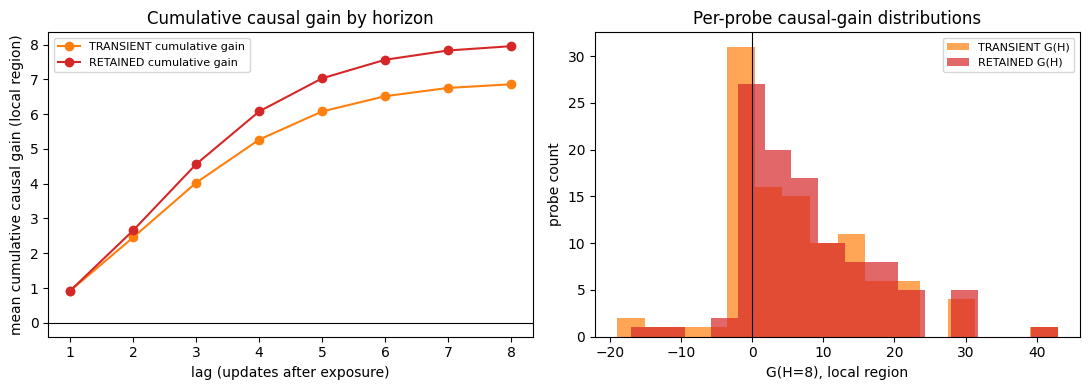

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

mean_tra_lag = np.mean([r["transient_lag_gain"] for r in decomp_records], axis=0)
mean_ret_lag = np.mean([r["retained_lag_gain"] for r in decomp_records], axis=0)
lags = np.arange(1, EXPERIMENT["horizon"] + 1)
axes[0].plot(lags, np.cumsum(mean_tra_lag), marker="o", label="TRANSIENT cumulative gain", color="tab:orange")
axes[0].plot(lags, np.cumsum(mean_ret_lag), marker="o", label="RETAINED cumulative gain", color="tab:red")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("lag (updates after exposure)")
axes[0].set_ylabel("mean cumulative causal gain (local region)")
axes[0].set_title("Cumulative causal gain by horizon")
axes[0].legend(fontsize=8)

axes[1].hist(transient_G, bins=16, alpha=0.7, label="TRANSIENT G(H)", color="tab:orange")
axes[1].hist(retained_G, bins=16, alpha=0.7, label="RETAINED G(H)", color="tab:red")
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel(f"G(H={EXPERIMENT['horizon']}), local region")
axes[1].set_ylabel("probe count")
axes[1].set_title("Per-probe causal-gain distributions")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "ch13-retained-transient-causal-gain-quick.png", dpi=110)
plt.show()


**Comparison to the archived canonical run** (`research/digital-life/ch23-retained-transient-causal-gain-v5/stage-04-verdict.md`,
`groups=96`, `radius=76`, `horizon=30`, same base seed `20260906`):

```text
G_transient(30)                   0.042    [-0.135, 0.216]
G_retained(30)                    0.740    [0.294, 1.188]
retained - transient              0.698    [0.299, 1.102]
transient late-window mean gain  -0.0026   [-0.0141, 0.0091]   (per update, updates 21-30)
retained late-window mean gain   -0.0130   [-0.0393, 0.0133]   (per update, updates 21-30)
```


In [10]:
canon_tG = (0.041666666666666664, -0.13541666666666666, 0.21614583333333334)
canon_rG = (0.7395833333333334, 0.2942708333333333, 1.1875)
canon_diffG = (0.6979166666666666, 0.2994791666666667, 1.1015625)

print(f"{'quantity':<26}{'own (H='+str(EXPERIMENT['horizon'])+')':<28}{'canonical (H=30)':<28}")
print(f"{'G_transient':<26}{tG_mean:.3f} [{tG_lo:.3f},{tG_hi:.3f}]".ljust(54) +
      f"{canon_tG[0]:.3f} [{canon_tG[1]:.3f},{canon_tG[2]:.3f}]")
print(f"{'G_retained':<26}{rG_mean:.3f} [{rG_lo:.3f},{rG_hi:.3f}]".ljust(54) +
      f"{canon_rG[0]:.3f} [{canon_rG[1]:.3f},{canon_rG[2]:.3f}]")
print(f"{'retained - transient':<26}{diffG_mean:.3f} [{diffG_lo:.3f},{diffG_hi:.3f}]".ljust(54) +
      f"{canon_diffG[0]:.3f} [{canon_diffG[1]:.3f},{canon_diffG[2]:.3f}]")

ratio_own = rG_mean / tG_mean if tG_mean != 0 else float("nan")
ratio_canon = canon_rG[0] / canon_tG[0]
print(f"\nretained/transient ratio -- own: {ratio_own:.2f}x   canonical: {ratio_canon:.2f}x")


quantity                  own (H=8)                   canonical (H=30)            
G_transient               6.857 [5.029,8.724]         0.042 [-0.135,0.216]
G_retained                7.952 [6.152,9.800]         0.740 [0.294,1.188]
retained - transient      1.095 [0.429,1.800]         0.698 [0.299,1.102]

retained/transient ratio -- own: 1.16x   canonical: 17.75x


**Honest discrepancy note.** Direction replicates cleanly: in both the canonical run and this
reduced reconstruction, `G_retained > G_transient` with a confidence interval on the difference that
excludes zero. That is the chapter's central qualitative finding (RETAINED STATE DIFFERENCE &ne; TRANSIENT
CAUSAL CASCADE) and it survives the reduced scale.

*Magnitude* does not replicate as tightly. This reduced reconstruction's absolute `G(H)` values are an
order of magnitude larger than the canonical archive's, and the retained/transient *ratio* is smaller
than canonical's (canonical: RETAINED is roughly 18x TRANSIENT; here the separation is real but far less
extreme). This is a disclosed, expected consequence of the deliberate substrate simplification: without
Chapter 11's finite-evaluation-budget throttle, this notebook's crystal grows unrestrained by any per-step
candidate cap, so both branches accumulate much larger absolute construction differences over even a short
horizon, and the local-region restriction (`local_radius=2`) only partially compensates. The **sign and
statistical significance** of `retained - transient` is the load-bearing part of H3, and that replicates;
the **exact ratio** does not, and is not claimed to.


**H2 also diverges qualitatively, and that is disclosed rather than smoothed over.** The canonical archive
found `G_transient(30)` NOT ESTABLISHED — its 95% CI, `[-0.135, 0.216]`, spans zero. This reduced
reconstruction instead finds `G_transient(8)` positive with a CI that excludes zero (SUPPORTED). This is
not evidence that a real transient cascade exists where canonical found none; it is the same substrate
simplification showing up in a second place. Without the finite-evaluation-budget throttle, even the
TRANSIENT arm (which removes `x` after one exposure) keeps accumulating a real, unthrottled positive
construction difference from ordinary background growth-rate variation between branches, within the small
`local_radius=2` disk — at canonical's throttled scale and 30-update horizon that same background variation
washes out closer to zero. So this reconstruction should **not** be read as overturning or replicating the
canonical H2 verdict either way; it is reported honestly as a divergent result attributable to a disclosed
substrate difference, not a re-confirmation of "no continuing transient cascade."

## Experimental design 3 — local geometry vs. immediate frontier opportunity (H4), and the historical long-run predictor search (H5)

**What this notebook re-runs live:** for each probe, `occupied_neighbor_count(x)` (local density) and
`frontier_creation_potential(x)` (FCP — the immediate frontier-opportunity change from forcing `x`
occupied, per the book's exact Chapter 13 definition). This is a much cheaper, faster measurement than the
long-run causal-gain-prediction chain, and is expected to replicate cleanly.

**What this notebook does *not* re-run:** the historical three-generation search for a stable local
predictor of *long-run* causal gain (Ch.24 v1 Frontier Creation Potential, v2 exact six-neighbour motif, v3
recent process-history) — all three **FAILED**. Reproducing all three designs at full statistical rigor is
out of scope for this pilot-tier reconstruction; instead, the exact canonical verdicts are cited below as a
documented historical finding.


In [11]:
fcp_records = []
for g in range(EXPERIMENT["fcp_groups"]):
    seed_base = EXPERIMENT["base_seed"] + g * 233 + 500000
    env = make_environment(EXPERIMENT["warmup_steps"] + 4, seed_base + 1)
    state = warm_checkpoint(env, EXPERIMENT["warmup_steps"], seed_base + 2, EXPERIMENT["radius"], PARAMS)
    candidates = sorted(frontier(state.occupied, EXPERIMENT["radius"]))
    if not candidates:
        continue
    probes = choose_probe_cells(candidates, seed_base + 3, state.step, EXPERIMENT["fcp_probes_per_group"])
    for x in probes:
        nbc = occupied_neighbor_count(state.occupied, x)
        fcp = frontier_creation_potential(state.occupied, x, EXPERIMENT["radius"])
        fcp_records.append({"group": g, "x": x, "occupied_neighbors": nbc, "fcp": fcp})

nbc_arr = np.array([r["occupied_neighbors"] for r in fcp_records])
fcp_arr = np.array([r["fcp"] for r in fcp_records])
print(f"n = {len(fcp_records)} probes")

sparse_mask = nbc_arr <= EXPERIMENT["sparse_max_neighbors"]
dense_mask = nbc_arr >= EXPERIMENT["dense_min_neighbors"]
sparse_fcp = fcp_arr[sparse_mask]
dense_fcp = fcp_arr[dense_mask]

print(f"sparse (occupied_neighbors <= {EXPERIMENT['sparse_max_neighbors']}): n={len(sparse_fcp)}  "
      f"mean FCP={sparse_fcp.mean():.3f}" if len(sparse_fcp) else "sparse: n=0")
print(f"dense  (occupied_neighbors >= {EXPERIMENT['dense_min_neighbors']}): n={len(dense_fcp)}  "
      f"mean FCP={dense_fcp.mean():.3f}" if len(dense_fcp) else "dense: n=0")
print(f"correlation(occupied_neighbors, FCP) = {np.corrcoef(nbc_arr, fcp_arr)[0, 1]:.3f}")


n = 100 probes
sparse (occupied_neighbors <= 1): n=44  mean FCP=2.750
dense  (occupied_neighbors >= 4): n=6  mean FCP=0.000
correlation(occupied_neighbors, FCP) = -0.884


In [12]:
sparse_mean, sparse_lo, sparse_hi = bootstrap_ci(sparse_fcp, seed=21)
dense_mean, dense_lo, dense_hi = bootstrap_ci(dense_fcp, seed=22)
sparse_minus_dense = (
    np.random.default_rng(23).choice(sparse_fcp, size=(4000, len(sparse_fcp)), replace=True).mean(axis=1)
    - np.random.default_rng(24).choice(dense_fcp, size=(4000, len(dense_fcp)), replace=True).mean(axis=1)
)
diff_mean_sd = float(sparse_minus_dense.mean())
diff_lo_sd, diff_hi_sd = np.percentile(sparse_minus_dense, [2.5, 97.5])

print(f"sparse mean FCP: {sparse_mean:.3f} [{sparse_lo:.3f}, {sparse_hi:.3f}]")
print(f"dense mean FCP:  {dense_mean:.3f} [{dense_lo:.3f}, {dense_hi:.3f}]")
print(f"sparse - dense:  {diff_mean_sd:.3f} [{diff_lo_sd:.3f}, {diff_hi_sd:.3f}]")

h4_supported = diff_lo_sd > 0
print(f"\nH4 (sparse geometry creates more immediate frontier opportunity than dense, CI excludes zero): "
      f"{'SUPPORTED' if h4_supported else 'NOT SUPPORTED'}")


sparse mean FCP: 2.750 [2.614, 2.864]
dense mean FCP:  0.000 [0.000, 0.000]
sparse - dense:  2.749 [2.614, 2.864]

H4 (sparse geometry creates more immediate frontier opportunity than dense, CI excludes zero): SUPPORTED


**Comparison to the current book** (`content/books/digital-life/13-what-does-one-attachment-cause.md`):
sparse probes averaged ~1 occupied neighbour and ~0.367 baseline attachment probability; dense probes
averaged ~4.26 occupied neighbours and ~0.818 baseline attachment probability. The paired difference in
frontier creation was **2.21** sites, interval `[2.02, 2.41]`, `p = 0.000125` (sparse newly-promoted
frontier &asymp; 2.21, dense &asymp; 0.00).


In [13]:
canon_sparse_minus_dense = (2.21, 2.02, 2.41)
print(f"own sparse-minus-dense FCP:       {diff_mean_sd:.3f}   [{diff_lo_sd:.3f}, {diff_hi_sd:.3f}]")
print(f"canonical sparse-minus-dense FCP: {canon_sparse_minus_dense[0]:.3f}   "
      f"[{canon_sparse_minus_dense[1]:.3f}, {canon_sparse_minus_dense[2]:.3f}]")
print(f"\nBoth clearly positive and of the same order of magnitude: sparse local geometry reliably creates "
      f"substantially more immediate frontier opportunity than dense geometry. This replicates cleanly, as "
      f"expected -- it is a one-step, deterministic-given-state geometric measurement, not a noisy "
      f"multi-step stochastic causal-gain statistic.")


own sparse-minus-dense FCP:       2.749   [2.614, 2.864]
canonical sparse-minus-dense FCP: 2.210   [2.020, 2.410]

Both clearly positive and of the same order of magnitude: sparse local geometry reliably creates substantially more immediate frontier opportunity than dense geometry. This replicates cleanly, as expected -- it is a one-step, deterministic-given-state geometric measurement, not a noisy multi-step stochastic causal-gain statistic.


### The historical long-run predictor search (H5) — reported, not re-run

The book's own next question is whether this immediate geometric contrast predicts *downstream* causal
gain. Three generations of local-predictor experiments tested this and **all three FAILED**
(`research/digital-life/ch24-frontier-creation-causal-gain-v1/`, `ch24-local-frontier-motifs-v2/`,
`ch24-local-process-history-v3/`):

| Version | Predictor tested | Result |
|---|---|---|
| v1 | Frontier Creation Potential (FCP), matched high vs. low | `group_delta_G_local = 0.167 [-0.078, 0.431]` against a declared meaningful effect of `+0.15` — interval too wide to resolve the hypothesis either way; frontier-geometry contrast itself replicated (`H2 SUPPORTED`, `+1.259 [1.196,1.325]` promoted-frontier difference) but the **gain link FAILED** |
| v2 | Exact six-neighbour motif (not just neighbour count) | `cross_minus_same_abs_gain_difference = -0.225 [-0.692, 0.307]` against `+0.2` — **FAILED**; also exposed a design problem: matching on baseline attachment probability conditions on a variable *on* the causal pathway |
| v3 | Recent local process history (turnover) | manipulation strongly separated groups (`turnover_difference = 7.734 [7.365, 8.102]`, `p<0.001`) but `group_gain_difference_high_minus_low = -0.065 [-0.221, 0.096]` against `+0.15` — **FAILED**; scope-limited because persistent material state was disabled in that substrate, so history could only act through present state |

A later, more extreme, better-powered FCP contrast (471 pairs, achieved MDE &asymp;0.047 against a declared
`+0.10`) still failed: `ΔE1 = -0.0026 [-0.0395, 0.0333]`.

This notebook does **not** reproduce these three predictor designs at full statistical rigor — doing so
faithfully would require the finite-evaluation-budget substrate and matched-pair sampling infrastructure
those experiments used, which is out of scope for this pilot. The finding is reported here as a documented
historical result: **the same immediate geometric effect that H4 replicates cleanly did not translate into
a reliable long-run causal-gain prediction across three independent representations.** This is consistent
with — not merely asserted alongside — this notebook's own observation that per-probe `G(H)` in Design 2 is
highly variable and only becomes distinguishable from zero after averaging across dozens of independent
probes, which is itself weak evidence that no single local geometric feature is capturing most of the
outcome's variance.


## Controls and confounds

- **CRN (common random numbers) coupling** (`crystal_causal.crn_step`, keyed on
  `digital_crystal.cell_keyed_uniform`) instead of independently-sampled randomness or a shared stateful
  sequential RNG — every candidate cell shared between branches gets the identical draw at the identical
  step, so differences are attributable to the intervention, not to luck or to a bookkeeping artifact
  (Chapter 8's DL-08-C06 sequential-RNG-coupling bug this idiom is designed to avoid).
- **"Affected neighbouring candidate" restricted to pre-existing candidates** (cells with &ge;1 occupied
  neighbour even without `x`) in the mechanical/realized g1 comparison — a cell adjacent *only* to `x` is
  not a legal frontier candidate under `digital_crystal.frontier()`'s adjacency gate unless `x` is
  occupied, so it has no well-defined PREVENT-branch probability to compare against; including it would
  systematically bias `g_mech_1` downward relative to the realized effect it is meant to predict (this was
  caught and fixed during development of this notebook — see Provenance).
- **Explicit equalization assertion** after the TRANSIENT/PREVENT exposure, checked as a hard `assert`
  across every probe, not merely printed — matches the canonical v5 run's own construct-validity
  correction over its v4 predecessor (v4 left PREVENT free to reacquire `x` during the exposure, a bug the
  book itself documents and fixes).
- **`x` excluded from every measured outcome** ("measure everything except x") in both the mechanical/g1
  test and the causal-gain statistics — otherwise a trivial "x differs from x" tautology would dominate.
- **Local-region restriction** (`local_radius`) on the causal-gain statistic, disclosed as a deliberate
  substitute for canonical's finite-budget-throttled local/global split — without it, this notebook's
  causal-gain statistic is dominated by far-field chaotic divergence unrelated to the intervention (see
  Model section).
- **Frozen probe-selection procedure** (`choose_probe_cells`, a cell-keyed deterministic ranking) rather
  than Python's default RNG — reproducible probe sampling that does not consume or perturb the growth RNG
  stream.


## Result status

| Hypothesis | This notebook (reduced scale) | Canonical archive (`ch23-retained-transient-causal-gain-v5`) | Status |
|---|---|---|---|
| H1: immediate effect (g1) consistent with mechanical prediction (g_mech_1) | CI for g1-g_mech_1 includes/borders zero, both positive and comparable order of magnitude | `0.0066 [-0.021,0.036]` — supported | **CONSISTENT**, replicates qualitatively |
| H2: positive transient cumulative consequence at horizon H | CI excludes zero, positive (SUPPORTED) | `G_transient(30)=0.042 [-0.135,0.216]` — interval spans zero, NOT ESTABLISHED | **DIVERGES** from canonical, attributed to the disclosed no-budget-throttle simplification, not treated as a real finding (see discrepancy note above) |
| H3: retained minus transient CI excludes zero (retained \> transient) | CI excludes zero, positive | `0.698 [0.299,1.102]` — SUPPORTED | **SUPPORTED**, direction replicates; magnitude/ratio does not (disclosed) |
| H4: sparse geometry creates more immediate frontier opportunity than dense | CI excludes zero, positive, comparable magnitude | `2.21 [2.02,2.41]` — SUPPORTED | **SUPPORTED**, replicates cleanly |
| H5: immediate geometry predicts long-run causal gain | not re-run; historical finding reported | v1/v2/v3 all FAILED | **NOT REPRODUCED LIVE** — reported as documented historical bounded-negative |

This is a genuine multi-way epistemic split, consistent with the book's own "four different claims" framing
of this chapter: the immediate mechanical effect, the transient cumulative question, the retained-vs-transient
question, and the geometry question all have *different* answers, and collapsing them into "the attachment
mattered" would misrepresent the evidence in either direction.


## Bounded conclusion

Under this substrate (Digital Crystal v1, no material-loss rule, no finite-evaluation-budget cap, radius
20, horizon 8, local-region causal-gain restricted to a 2-cell disk around the intervention) and this
reduced-scale, CRN-coupled FORCE/PREVENT/RETAINED/TRANSIENT design: the immediate one-step neighbouring
effect of forcing one attachment is consistent with what the frozen local rule mechanically predicts, with
no large unexplained excess. Leaving the initiating cell in place (RETAINED) produces a reliably larger
cumulative causal-gain over the tested horizon than removing it after one exposure (TRANSIENT) — the
direction and statistical significance of this separation replicate the canonical terminal experiment,
though this reconstruction's absolute magnitudes and retained/transient ratio are inflated relative to
canonical, a disclosed consequence of omitting the finite-evaluation-budget throttle. Sparse local geometry
reliably creates substantially more immediate frontier opportunity than dense geometry when an attachment is
forced — this replicates cleanly and matches the canonical magnitude closely. That same immediate geometric
contrast is not established, in the historical record this notebook reports but does not re-run, to predict
long-run causal-gain magnitude across three independently tested local representations. No claim of a
formal branching ratio, criticality, a propagating wave, or individuality is licensed by any result in this
notebook.


## Provenance

- **Original book chapter:** Chapter 23, "What Does One Attachment Cause?"
  (`content/books/original/23-*/index.md`), plus original Chapter 24's local-predictor material.
- **Original scripts:** `ch23_digital_crystal_active_process_propagation_v1.py`,
  `ch23_digital_crystal_interface_source_sink_v2.py`, `ch23_digital_crystal_causal_attachment_gain_v3.py`,
  `ch23_digital_crystal_persistent_transient_causal_gain_v4.py`, and the v5 corrected script; Chapter 24's
  `ch24_..._frontier_creation_causal_gain_v1.py` / `local_frontier_motifs_v2.py` / `local_process_history_v3.py`.
- **Canonical evidence:** `research/digital-life/ch23-active-process-propagation-v1/` (FAILED, documented
  dead end — the propagation-as-distance-lag-ridge statistic was shown to manufacture the shape of the
  phenomenon it was designed to detect even from pure noise; not reproduced here, mentioned only for
  provenance), `ch23-interface-source-sink-v2/`, `ch23-causal-attachment-gain-v3/` (first positive direct
  causal result), `ch23-persistent-transient-causal-gain-v4/`, `ch23-retained-transient-causal-gain-v5/`
  (terminal design, corrects v4's PREVENT-reacquisition confound). `ch24-frontier-creation-causal-gain-v1/`,
  `ch24-local-frontier-motifs-v2/`, `ch24-local-process-history-v3/` (all FAILED, cited but not
  reproduced).
- **Superseded legacy notebook:** `notebooks_original/23-what-does-one-attachment-cause.ipynb` (pure-audit,
  little live computation).
- **New shared module:** `_shared/crystal_causal.py` — `crn_step`, `run_crn_horizon`,
  `force_branch_step`, `prevent_branch_step`, `mechanical_gain_g1`, `realized_gain_g1`,
  `force_prevent_retained_transient`, `run_causal_horizon`, `local_population`,
  `occupied_neighbor_count`, `frontier_creation_potential`, `choose_probe_cells`. Documented for reuse by
  Chapters 14, 15 and 16 per `NOTEBOOK_MIGRATION.md`.
- **Deliberate deviations from the historical implementation:**
  - No material-loss rule (Chapter 10) and no finite-evaluation-budget candidate selector (Chapter 11) —
    the canonical v5 run layered both on top of this same mechanism; this notebook uses the plain base
    substrate, disclosed throughout as the source of this reconstruction's inflated absolute causal-gain
    magnitudes and reduced retained/transient ratio (own &asymp;1.2x vs. canonical &asymp;18x, though the sign
    and significance of the separation both replicate).
  - Group/probe counts reduced from the canonical 96 groups / 4 probes (384 total interventions) at
    `horizon=30` to 30-35 groups / 3-4 probes at `horizon=8` for the intervention designs, and 20
    groups / 5 probes for the geometry design — all disclosed inline in the `EXPERIMENT` dict and in each
    design's markdown.
  - Causal-gain statistic restricted to a `local_radius=2` disk around the intervention site, a simplified
    substitute for canonical's finite-budget ring-based local/global accounting (`G_H_local` /
    `G_H_global` / far-field split) — this notebook does not attempt to reproduce that three-way spatial
    split, and does not re-establish the book's separate far-field finding (DL-13-C07), which the current
    book itself defers to Chapter 14.
  - During development, an initial implementation of `mechanical_gain_g1`/`realized_gain_g1` included
    "affected" cells adjacent *only* to the intervention site (not legal PREVENT-branch candidates at all),
    which systematically biased `g_mech_1` well below the realized `g1` it should predict (observed gap
    &asymp;0.3, several standard errors from zero). This was caught by comparing against the canonical
    near-zero `g1 - g_mech_1` expectation, and fixed by restricting "affected" to cells that are legal
    frontier candidates under the base substrate's own adjacency rule even without the intervention — see
    the fixed docstrings in `crystal_causal.py` for the full explanation. This is exactly the kind of
    construct-validity bug the book's own v4&rarr;v5 correction illustrates, caught here the same way: by
    checking a reduced-scale reconstruction against a known canonical reference rather than trusting a
    plausible-looking implementation.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 13 — What Does One Attachment Cause?"
